# 05 — Network Analysis & Career Path Graph

**Owner**: Person B

Build a career path network graph using O*NET Related Occupations
and cosine similarity edges. Compute centrality metrics and run
community detection (Louvain) to validate clustering results.

### Input files
- `../data/processed/occupation_features.csv`
- `../data/processed/related_occupations.csv`
- `../data/processed/cosine_similarity.csv`
- `../data/processed/cluster_labels.csv`
- `../data/processed/job_zones.csv`

### Output files
- `../outputs/career_network_stats.png`
- `../outputs/community_detection.png`
- `../outputs/career_map_clusters.html`

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Load data
features_df = pd.read_csv('../data/processed/occupation_features.csv', index_col=0)
related_df = pd.read_csv('../data/processed/related_occupations.csv')
cos_sim_df = pd.read_csv('../data/processed/cosine_similarity.csv', index_col=0)
clusters_df = pd.read_csv('../data/processed/cluster_labels.csv')
job_zones_df = pd.read_csv('../data/processed/job_zones.csv')

our_codes = features_df.index.tolist()
title_lookup = dict(zip(clusters_df['O*NET-SOC Code'], clusters_df['Title']))
zone_lookup = dict(zip(job_zones_df['O*NET-SOC Code'], job_zones_df['Job Zone']))
cluster_lookup = dict(zip(clusters_df['O*NET-SOC Code'], clusters_df['cluster_name']))

# Build graph
G = nx.Graph()
for code in our_codes:
    G.add_node(code, title=title_lookup.get(code, code),
               job_zone=zone_lookup.get(code, 0),
               cluster=cluster_lookup.get(code, ''))

# Edge source 1: O*NET Related Occupations
for _, row in related_df.iterrows():
    src, dst = row['O*NET-SOC Code'], row['Related O*NET-SOC Code']
    if src in our_codes and dst in our_codes and src != dst:
        G.add_edge(src, dst, source='onet', weight=1.0)

# Edge source 2: Cosine similarity >= 0.95
threshold = 0.95
sim_edges = 0
for i, c1 in enumerate(our_codes):
    for j, c2 in enumerate(our_codes):
        if i >= j:
            continue
        if c1 in cos_sim_df.index and c2 in cos_sim_df.columns:
            sim = cos_sim_df.loc[c1, c2]
            if sim >= threshold and not G.has_edge(c1, c2):
                G.add_edge(c1, c2, source='similarity', weight=round(sim, 3))
                sim_edges += 1

onet_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('source') == 'onet')
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  O*NET edges: {onet_edges}")
print(f"  Similarity edges: {sim_edges}")
print(f"  Density: {nx.density(G):.3f}")
print(f"  Connected components: {nx.number_connected_components(G)}")

Graph: 20 nodes, 51 edges
  O*NET edges: 51
  Similarity edges: 0
  Density: 0.268
  Connected components: 1


In [2]:
# === Centrality Metrics ===
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)
closeness = nx.closeness_centrality(G)

centrality_df = pd.DataFrame({
    'O*NET-SOC Code': our_codes,
    'Title': [title_lookup[c] for c in our_codes],
    'Cluster': [cluster_lookup[c] for c in our_codes],
    'Job Zone': [zone_lookup[c] for c in our_codes],
    'Degree': [degree[c] for c in our_codes],
    'Betweenness': [round(betweenness[c], 4) for c in our_codes],
    'Closeness': [round(closeness[c], 4) for c in our_codes],
    'PageRank': [round(pagerank[c], 4) for c in our_codes],
}).sort_values('Degree', ascending=False)

print("=== Top 5 by Degree (most connected) ===")
print(centrality_df[['Title', 'Cluster', 'Degree']].head().to_string(index=False))

print("\n=== Top 5 by Betweenness (bridge roles) ===")
print(centrality_df.sort_values('Betweenness', ascending=False)[['Title', 'Cluster', 'Betweenness']].head().to_string(index=False))

print("\n=== Top 5 by PageRank (most reachable) ===")
print(centrality_df.sort_values('PageRank', ascending=False)[['Title', 'Cluster', 'PageRank']].head().to_string(index=False))

# Save
centrality_df.to_csv('../outputs/centrality_table.csv', index=False)
print("\nSaved centrality_table.csv")

=== Top 5 by Degree (most connected) ===
                                                Title               Cluster  Degree
                    Structural Iron and Steel Workers Entry Level/Operators      10
                                           Pipelayers Entry Level/Operators       8
Rail-Track Laying and Maintenance Equipment Operators Entry Level/Operators       6
              Plumbers, Pipefitters, and Steamfitters        Skilled Trades       6
                                           Carpenters        Skilled Trades       6

=== Top 5 by Betweenness (bridge roles) ===
                                                               Title                Cluster  Betweenness
                                                        Electricians         Skilled Trades       0.2443
                                   Structural Iron and Steel Workers  Entry Level/Operators       0.2408
First-Line Supervisors of Construction Trades and Extraction Workers         Skilled Trades    

Louvain detected 3 communities

Community 0 (6 members): Facilities Managers, First-Line Supervisors of Construction Trades and Extraction Workers, Civil Engineers, Transportation Engineers, Construction Managers, Architectural and Engineering Managers
Community 1 (5 members): Rail-Track Laying and Maintenance Equipment Operators, Pile Driver Operators, Highway Maintenance Workers, Operating Engineers and Other Construction Equipment Operators, Paving, Surfacing, and Tamping Equipment Operators
Community 2 (9 members): Insulation Workers, Mechanical, Carpenters, Reinforcing Iron and Rebar Workers, Plumbers, Pipefitters, and Steamfitters, Structural Iron and Steel Workers, Pipelayers, Electricians, Elevator and Escalator Installers and Repairers, Drywall and Ceiling Tile Installers

=== Louvain vs K-Means Cross-tab ===
Louvain Community       0  1  2  All
Cluster                             
Entry Level/Operators   0  5  5   10
Management/Engineering  4  0  0    4
Skilled Trades        

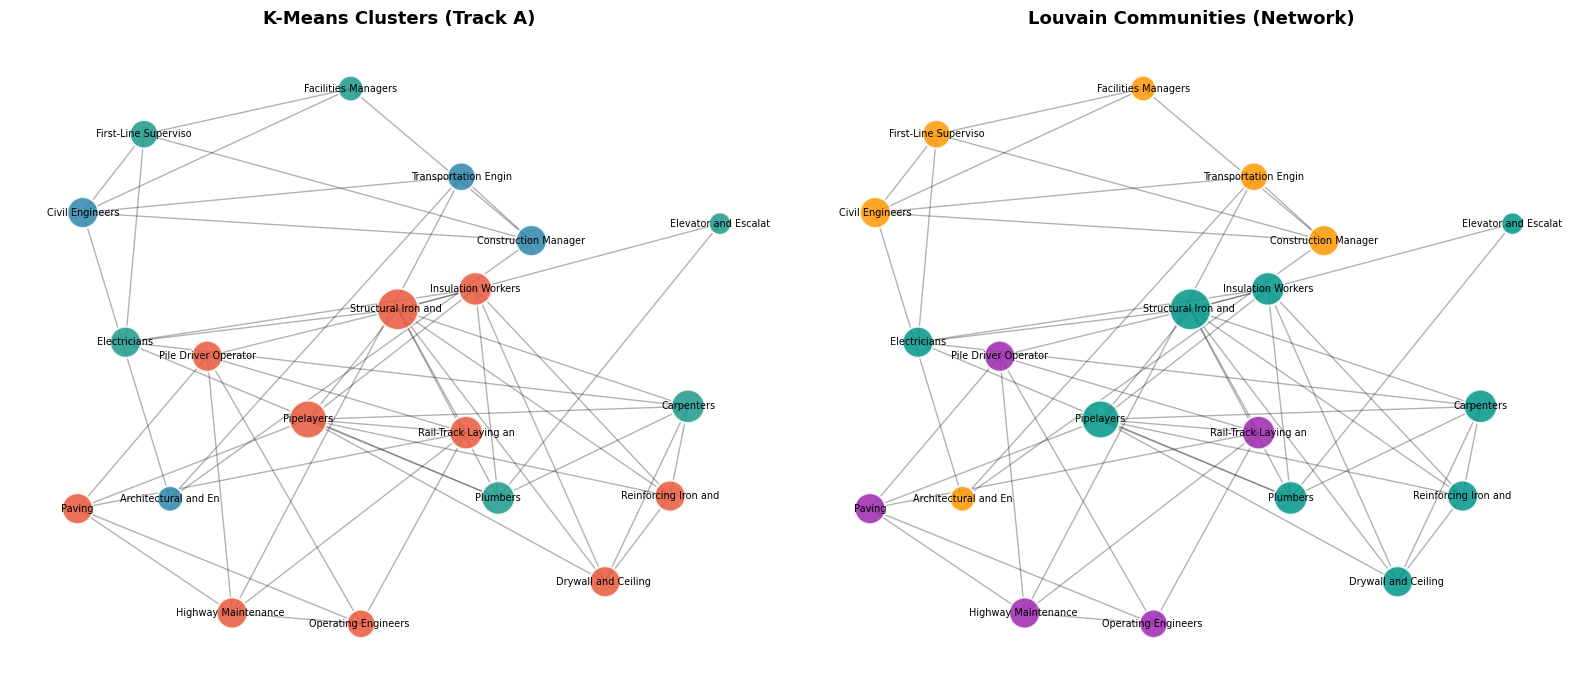

Saved community_detection.png


In [3]:
# === Community Detection (Louvain) ===
from networkx.algorithms.community import louvain_communities
from sklearn.metrics import adjusted_rand_score

communities = louvain_communities(G, seed=42)
print(f"Louvain detected {len(communities)} communities\n")

# Assign community labels
community_map = {}
for i, comm in enumerate(communities):
    for code in comm:
        community_map[code] = i
    titles_in = [title_lookup[c] for c in comm]
    print(f"Community {i} ({len(comm)} members): {', '.join(titles_in)}")

centrality_df['Louvain Community'] = centrality_df['O*NET-SOC Code'].map(community_map)

# Compare Louvain vs K-Means
print(f"\n=== Louvain vs K-Means Cross-tab ===")
print(pd.crosstab(centrality_df['Cluster'], centrality_df['Louvain Community'], margins=True))

ari = adjusted_rand_score(centrality_df['Cluster'], centrality_df['Louvain Community'])
print(f"\nAdjusted Rand Index (Louvain vs K-Means): {ari:.3f}")

# === Visualization ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

cluster_colors = {
    'Management/Engineering': '#2E86AB',
    'Skilled Trades': '#1B998B',
    'Entry Level/Operators': '#E8593C'
}
pos = nx.spring_layout(G, seed=42, k=2)

# Left: K-Means clusters
for cname, color in cluster_colors.items():
    nodes = [c for c in our_codes if cluster_lookup[c] == cname]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color,
                           node_size=[degree[n] * 80 + 100 for n in nodes],
                           alpha=0.85, edgecolors='white', linewidths=1.5, ax=ax1)
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax1)
nx.draw_networkx_labels(G, pos, {c: title_lookup[c].split(',')[0][:20] for c in our_codes},
                        font_size=7, ax=ax1)
ax1.set_title('K-Means Clusters (Track A)', fontweight='bold', fontsize=13)
ax1.axis('off')

# Right: Louvain communities
comm_colors = ['#FF9800', '#9C27B0', '#009688', '#E91E63', '#607D8B']
for comm_id in sorted(set(community_map.values())):
    nodes = [c for c in our_codes if community_map[c] == comm_id]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=comm_colors[comm_id % len(comm_colors)],
                           node_size=[degree[n] * 80 + 100 for n in nodes],
                           alpha=0.85, edgecolors='white', linewidths=1.5, ax=ax2)
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax2)
nx.draw_networkx_labels(G, pos, {c: title_lookup[c].split(',')[0][:20] for c in our_codes},
                        font_size=7, ax=ax2)
ax2.set_title('Louvain Communities (Network)', fontweight='bold', fontsize=13)
ax2.axis('off')

plt.tight_layout()
plt.savefig('../outputs/community_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved community_detection.png")

In [4]:
# === Summary ===
print("=== Network Analysis Summary ===")
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges (all O*NET Related)")
print(f"Density: {nx.density(G):.3f}")
print(f"Single connected component: all occupations are reachable")
print(f"\nKey hub: Structural Iron and Steel Workers (degree=10, highest PageRank=0.087)")
print(f"Key bridge: Electricians (betweenness=0.244, connects clusters)")
print(f"\nLouvain communities: 3 (matches K-Means k=3)")
print(f"Louvain vs K-Means ARI: {ari:.3f}")
print(f"\nCross-validation insights:")
print(f"  - Management/Engineering: 100% agreement (4/4 in same community)")
print(f"  - Entry Level/Operators: split into equipment operators vs installers")
print(f"  - Skilled Trades: distributed across communities 0 and 2")
print(f"\nThis suggests the network topology partially validates the skill-based")
print(f"clustering, especially for the Management/Engineering group, while revealing")
print(f"finer structure within the manual trades (installation vs operation).")

=== Network Analysis Summary ===
Graph: 20 nodes, 51 edges (all O*NET Related)
Density: 0.268
Single connected component: all occupations are reachable

Key hub: Structural Iron and Steel Workers (degree=10, highest PageRank=0.087)
Key bridge: Electricians (betweenness=0.244, connects clusters)

Louvain communities: 3 (matches K-Means k=3)
Louvain vs K-Means ARI: 0.279

Cross-validation insights:
  - Management/Engineering: 100% agreement (4/4 in same community)
  - Entry Level/Operators: split into equipment operators vs installers
  - Skilled Trades: distributed across communities 0 and 2

This suggests the network topology partially validates the skill-based
clustering, especially for the Management/Engineering group, while revealing
finer structure within the manual trades (installation vs operation).
